# WhatsApp Chat Analyzer

Rename your chat txt to sample.txt and keep it in same directory as this or change path in Load Data section

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urlextract import URLExtract
from wordcloud import WordCloud
from collections import Counter
import emoji
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

extract = URLExtract()

## Preprocessing

In [2]:
def preprocess(data):
    patterns = [
        (r'\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s[APap][Mm]\s-\s', '%m/%d/%y, %I:%M %p - '),
        (r'\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s-\s', '%d/%m/%Y, %H:%M - '),
        (r'\[\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}:\d{2}\]\s', '[%d/%m/%y, %H:%M:%S] '),
    ]
    
    pattern = None
    date_format = None
    for p, fmt in patterns:
        matches = re.findall(p, data)
        if matches:
            pattern = p
            date_format = fmt
            print(f"Detected date format: {fmt}")
            print(f"Example: {matches[0]}")
            break
    
    if pattern is None:
        print("Could not detect date format in the chat file.")
        return pd.DataFrame()
    
    messages = re.split(pattern, data)[1:]
    dates = re.findall(pattern, data)
    print(f"Found {len(messages)} messages")

    df = pd.DataFrame({'user_message': messages, 'message_date': dates})
    
    try:
        df['message_date'] = pd.to_datetime(df['message_date'], format=date_format)
    except:
        df['message_date'] = pd.to_datetime(df['message_date'].str.replace(' - ', '').str.replace(' AM', ' AM').str.replace(' PM', ' PM'), dayfirst=False)
    
    df.rename(columns={'message_date': 'date'}, inplace=True)

    users = []
    messages_list = []
    for message in df['user_message']:
        entry = re.split(r'^([^:]+?):\s', message, maxsplit=1)
        if len(entry) > 1:
            users.append(entry[1].strip())
            messages_list.append(entry[2] if len(entry) > 2 else '')
        else:
            users.append('group_notification')
            messages_list.append(entry[0])

    df['user'] = users
    df['message'] = messages_list
    df.drop(columns=['user_message'], inplace=True)

    df['only_date'] = df['date'].dt.date
    df['year'] = df['date'].dt.year
    df['month_num'] = df['date'].dt.month
    df['month'] = df['date'].dt.month_name()
    df['day'] = df['date'].dt.day
    df['day_name'] = df['date'].dt.day_name()
    df['hour'] = df['date'].dt.hour
    df['minute'] = df['date'].dt.minute

    period = []
    for hour in df['hour']:
        if hour == 23:
            period.append(str(hour) + "-" + str('00'))
        elif hour == 0:
            period.append(str('00') + "-" + str(hour + 1))
        else:
            period.append(str(hour) + "-" + str(hour + 1))

    df['period'] = period
    return df

## Helper Functions

In [3]:
SYSTEM_MESSAGE_PATTERNS = [
    'joined using', 'left the group', 'was added', 'was removed',
    'changed the', 'created group', 'changed this group', 'pinned a message',
    'security code', 'Messages and calls are end-to-end encrypted',
    'You joined', 'turned on admin approval', 'Only admins can',
    '<Media omitted>', '<This message was edited>', 'image omitted',
    'video omitted', 'audio omitted', 'sticker omitted', 'GIF omitted',
    'document omitted', 'Contact card omitted', 'Missed voice call', 'Missed video call',
]

def is_actual_message(message, user):
    if user == 'group_notification':
        return False
    msg_str = str(message).strip()
    for pattern in SYSTEM_MESSAGE_PATTERNS:
        if pattern.lower() in msg_str.lower():
            return False
    if len(msg_str) < 2:
        return False
    return True

def fetch_stats(selected_user, df):
    if selected_user != 'Overall':
        df = df[df['user'] == selected_user]
    num_messages = df.shape[0]
    words = []
    for message in df['message']:
        words.extend(str(message).split())
    num_media_messages = df[df['message'].str.contains('<Media omitted>', na=False)].shape[0]
    links = []
    for message in df['message']:
        links.extend(extract.find_urls(str(message)))
    return num_messages, len(words), num_media_messages, len(links)

def most_busy_users(df):
    x = df['user'].value_counts().head()
    percent_df = round((df['user'].value_counts() / df.shape[0]) * 100, 2).reset_index()
    percent_df.columns = ['name', 'percent']
    return x, percent_df

def create_wordcloud(selected_user, df, stop_words):
    if selected_user != 'Overall':
        df = df[df['user'] == selected_user]
    temp = df[df.apply(lambda row: is_actual_message(row['message'], row['user']), axis=1)].copy()
    def remove_stop_words(message):
        y = []
        for word in str(message).lower().split():
            if word not in stop_words:
                y.append(word)
        return " ".join(y)
    wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
    temp['message'] = temp['message'].apply(remove_stop_words)
    text = temp['message'].str.cat(sep=" ")
    if text.strip():
        df_wc = wc.generate(text)
        return df_wc
    return None

def most_common_words(selected_user, df, stop_words, top_n=20):
    if selected_user != 'Overall':
        df = df[df['user'] == selected_user]
    temp = df[df.apply(lambda row: is_actual_message(row['message'], row['user']), axis=1)]
    words = []
    for message in temp['message']:
        for word in str(message).lower().split():
            if word in stop_words:
                continue
            if word.startswith('http') or word.startswith('www.'):
                continue
            if len(word) < 2:
                continue
            if word.isdigit():
                continue
            words.append(word)
    if words:
        most_common_df = pd.DataFrame(Counter(words).most_common(top_n))
        most_common_df.columns = ['word', 'count']
        return most_common_df
    return pd.DataFrame(columns=['word', 'count'])

def emoji_helper(selected_user, df):
    if selected_user != 'Overall':
        df = df[df['user'] == selected_user]
    emojis = []
    for message in df['message']:
        emojis.extend([c for c in str(message) if c in emoji.EMOJI_DATA])
    emoji_df = pd.DataFrame(Counter(emojis).most_common(len(Counter(emojis))))
    if not emoji_df.empty:
        emoji_df.columns = ['emoji', 'count']
    return emoji_df

def monthly_timeline(selected_user, df):
    if selected_user != 'Overall':
        df = df[df['user'] == selected_user]
    timeline = df.groupby(['year', 'month_num', 'month']).count()['message'].reset_index()
    time = []
    for i in range(timeline.shape[0]):
        time.append(timeline['month'][i] + "-" + str(timeline['year'][i]))
    timeline['time'] = time
    return timeline

def daily_timeline(selected_user, df):
    if selected_user != 'Overall':
        df = df[df['user'] == selected_user]
    daily_tl = df.groupby('only_date').count()['message'].reset_index()
    return daily_tl

def week_activity_map(selected_user, df):
    if selected_user != 'Overall':
        df = df[df['user'] == selected_user]
    return df['day_name'].value_counts()

def month_activity_map(selected_user, df):
    if selected_user != 'Overall':
        df = df[df['user'] == selected_user]
    return df['month'].value_counts()

def activity_heatmap(selected_user, df):
    if selected_user != 'Overall':
        df = df[df['user'] == selected_user]
    user_heatmap = df.pivot_table(index='day_name', columns='period', values='message', aggfunc='count').fillna(0)
    return user_heatmap

## Load Data

In [4]:
CHAT_FILE_PATH = "sample.txt"
STOP_WORDS_PATH = "sampling/stop_hinglish.txt"

try:
    with open(CHAT_FILE_PATH, 'r', encoding='utf-8') as f:
        data = f.read()
    print(f"Chat file loaded successfully!")
    print(f"File size: {len(data):,} characters")
except FileNotFoundError:
    print(f"File not found: {CHAT_FILE_PATH}")
    data = None

try:
    with open(STOP_WORDS_PATH, 'r', encoding='utf-8') as f:
        stop_words = set(f.read().split())
    print(f"Stop words loaded: {len(stop_words)} words")
except FileNotFoundError:
    print(f"Stop words file not found. Using empty list.")
    stop_words = set()

Chat file loaded successfully!
File size: 8,422 characters
Stop words loaded: 1055 words


## Preprocess Data

In [5]:
if data:
    df = preprocess(data)
    if not df.empty:
        print(f"\nData preprocessed successfully!")
        print(f"Total messages: {len(df):,}")
        print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
        print(f"Unique users: {df['user'].nunique()}")
        actual_msg_count = df.apply(lambda row: is_actual_message(row['message'], row['user']), axis=1).sum()
        print(f"Actual user messages: {actual_msg_count}")
        print(f"System/notification messages: {len(df) - actual_msg_count}")
        print("\nFirst 5 rows:")
        display(df.head())
    else:
        print("Preprocessing failed. Check the date format in your chat file.")
else:
    print("No data to process. Please load a valid chat file.")

Detected date format: %m/%d/%y, %I:%M %p - 
Example: 12/17/25, 9:33 PM - 
Found 82 messages

Data preprocessed successfully!
Total messages: 82
Date range: 2025-12-17 to 2026-01-20
Unique users: 18
Actual user messages: 41
System/notification messages: 41

First 5 rows:


,date,user,message,only_date,year,month_num,month,day,day_name,hour,minute,period
0,2025-12-17 21:33:00,group_notification,Messages and calls are end-to-end encrypted. O...,2025-12-17,2025,12,December,17,Wednesday,21,33,21-22
1,2025-12-17 19:34:00,group_notification,"~ Abhishek Gupta created group ""DreamVentz Tec...",2025-12-17,2025,12,December,17,Wednesday,19,34,19-20
2,2025-12-17 21:33:00,group_notification,You joined using this group's invite link\n,2025-12-17,2025,12,December,17,Wednesday,21,33,21-22
3,2025-12-17 21:33:00,group_notification,+91 91370 52007 joined using a group link.\n,2025-12-17,2025,12,December,17,Wednesday,21,33,21-22
4,2025-12-17 21:37:00,group_notification,Mayuresh VIT joined using a group link.\n,2025-12-17,2025,12,December,17,Wednesday,21,37,21-22


## Select User

In [6]:
user_list = df['user'].unique().tolist()
if 'group_notification' in user_list:
    user_list.remove('group_notification')
user_list.sort()
user_list.insert(0, "Overall")

print("Available users:")
for i, user in enumerate(user_list):
    print(f"  {i}. {user}")

selected_user = "Overall"
print(f"\nSelected user: {selected_user}")

Available users:
  0. Overall
  1. +91 79778 63354
  2. +91 83560 29841
  3. +91 84248 11950
  4. +91 84519 16094
  5. +91 86575 09239
  6. +91 90218 94559
  7. +91 90825 16642
  8. +91 91370 52007
  9. +91 91370 89605
  10. +91 93216 06141
  11. +91 93569 44763
  12. +91 93736 09631
  13. +91 99607 98019
  14. 123456789
  15. Aditya Chavan
  16. Aryan Kulkarni VIT
  17. Mayuresh VIT

Selected user: Overall


---
## Analysis Results
---

### Statistics

In [7]:
num_messages, words, num_media_messages, num_links = fetch_stats(selected_user, df)

print("="*40)
print("STATISTICS")
print("="*40)
print(f"Total Messages:    {num_messages:,}")
print(f"Total Words:       {words:,}")
print(f"Media Shared:      {num_media_messages:,}")
print(f"Links Shared:      {num_links:,}")
print("="*40)

STATISTICS
Total Messages:    82
Total Words:       990
Media Shared:      0
Links Shared:      3


### Monthly Timeline

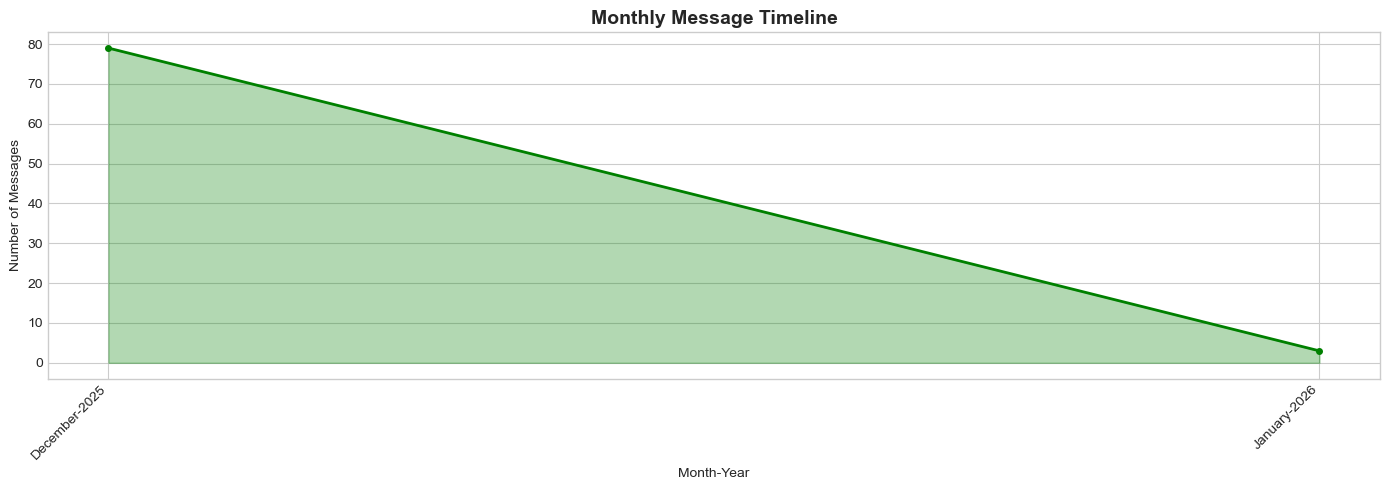

In [8]:
timeline = monthly_timeline(selected_user, df)

if not timeline.empty:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(timeline['time'], timeline['message'], color='green', linewidth=2, marker='o', markersize=4)
    ax.fill_between(range(len(timeline)), timeline['message'], alpha=0.3, color='green')
    ax.set_xticks(range(len(timeline)))
    ax.set_xticklabels(timeline['time'], rotation=45, ha='right')
    plt.xlabel('Month-Year')
    plt.ylabel('Number of Messages')
    plt.title('Monthly Message Timeline', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No data available for monthly timeline.")

### Daily Timeline

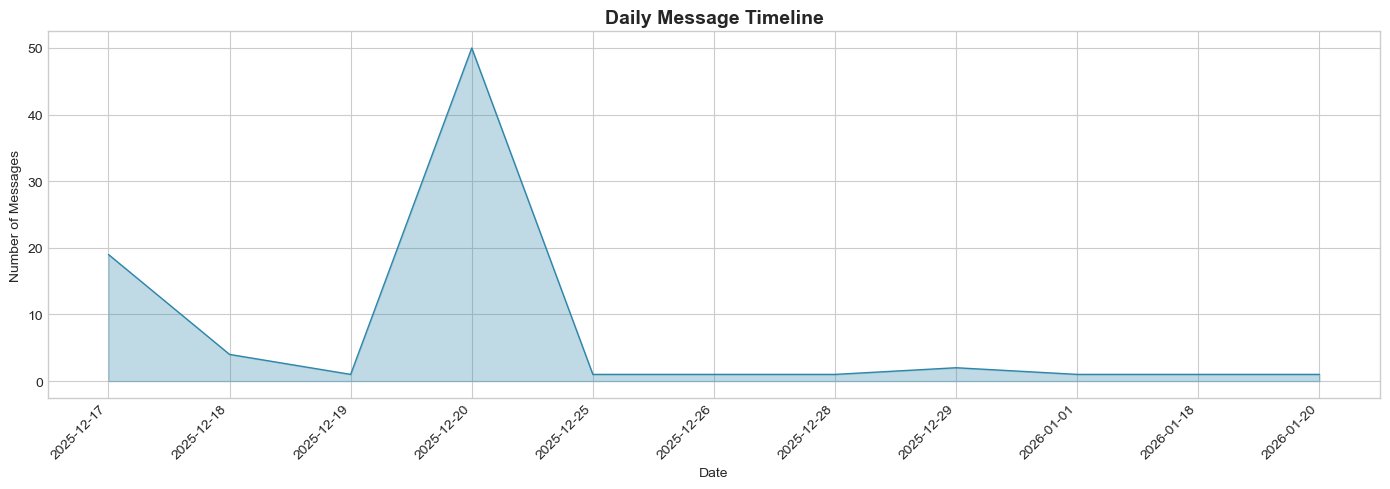

In [9]:
daily_tl = daily_timeline(selected_user, df)

if not daily_tl.empty:
    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(len(daily_tl))
    ax.plot(x, daily_tl['message'], color='#2E86AB', linewidth=1)
    ax.fill_between(x, daily_tl['message'], alpha=0.3, color='#2E86AB')
    n = max(1, len(daily_tl) // 10)
    ax.set_xticks(x[::n])
    ax.set_xticklabels([str(d) for d in daily_tl['only_date'].iloc[::n]], rotation=45, ha='right')
    plt.xlabel('Date')
    plt.ylabel('Number of Messages')
    plt.title('Daily Message Timeline', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No data available for daily timeline.")

### Activity Map

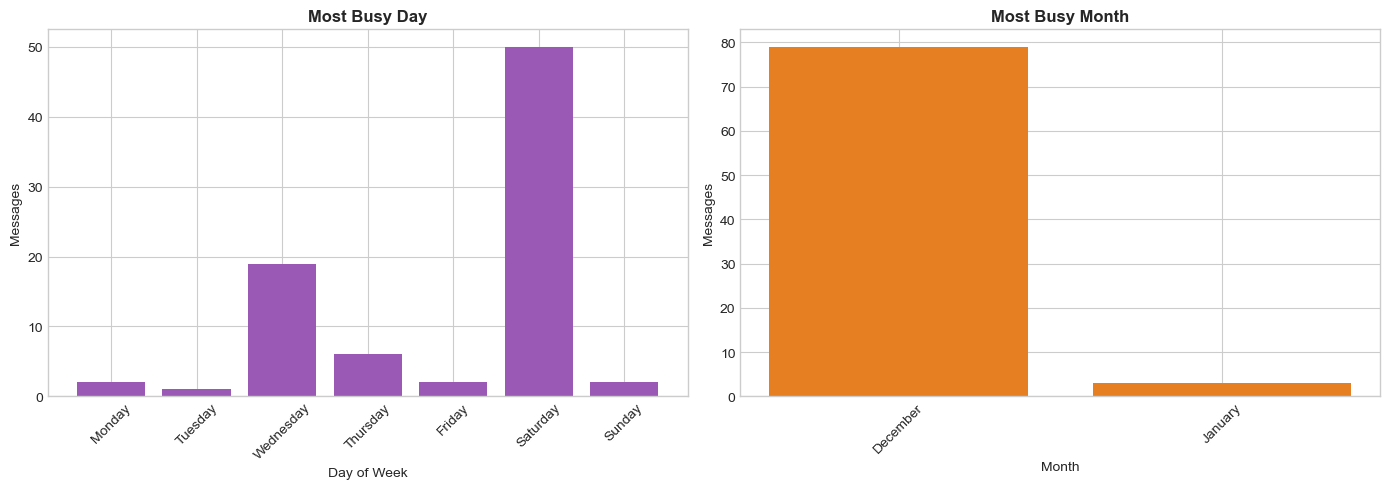

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

busy_day = week_activity_map(selected_user, df)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
busy_day = busy_day.reindex(day_order).dropna()
if not busy_day.empty:
    axes[0].bar(busy_day.index, busy_day.values, color='#9B59B6')
    axes[0].set_title('Most Busy Day', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Day of Week')
    axes[0].set_ylabel('Messages')
    axes[0].tick_params(axis='x', rotation=45)

busy_month = month_activity_map(selected_user, df)
if not busy_month.empty:
    axes[1].bar(busy_month.index, busy_month.values, color='#E67E22')
    axes[1].set_title('Most Busy Month', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Messages')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Weekly Activity Heatmap

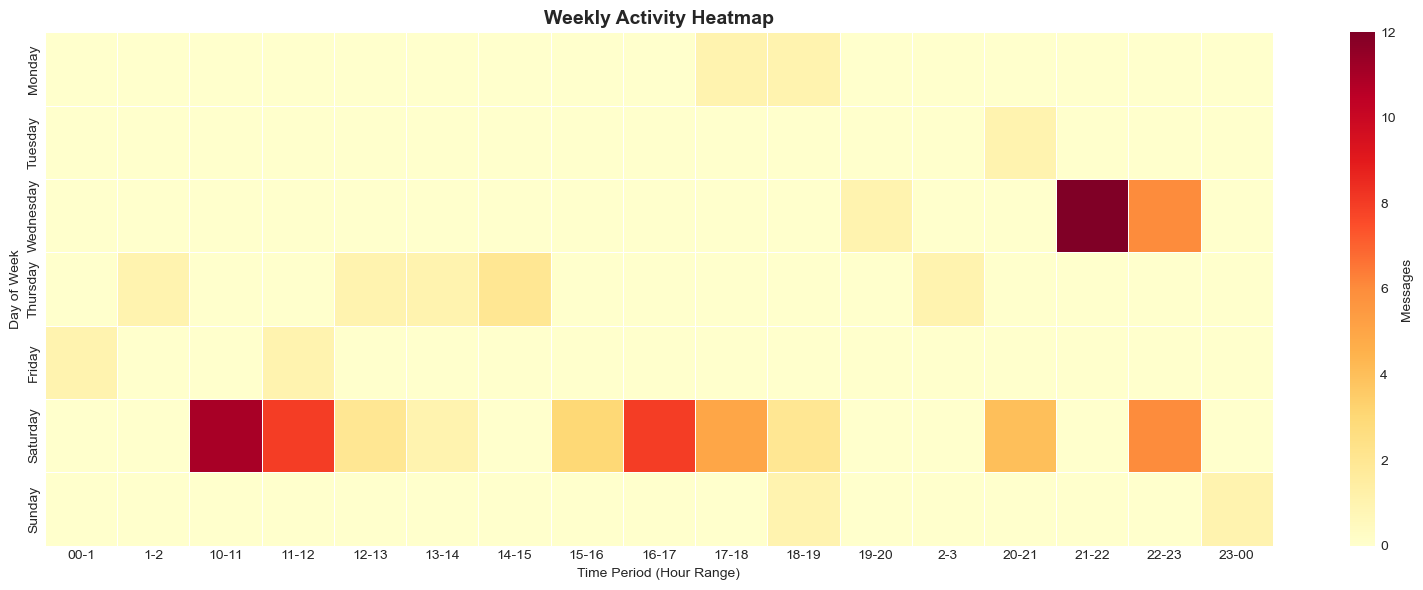

In [11]:
user_heatmap = activity_heatmap(selected_user, df)

if not user_heatmap.empty:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    available_days = [d for d in day_order if d in user_heatmap.index]
    user_heatmap = user_heatmap.reindex(available_days)
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.heatmap(user_heatmap, cmap='YlOrRd', linewidths=0.5, ax=ax, cbar_kws={'label': 'Messages'})
    plt.title('Weekly Activity Heatmap', fontsize=14, fontweight='bold')
    plt.xlabel('Time Period (Hour Range)')
    plt.ylabel('Day of Week')
    plt.tight_layout()
    plt.show()
else:
    print("No data available for heatmap.")

### Most Busy Users

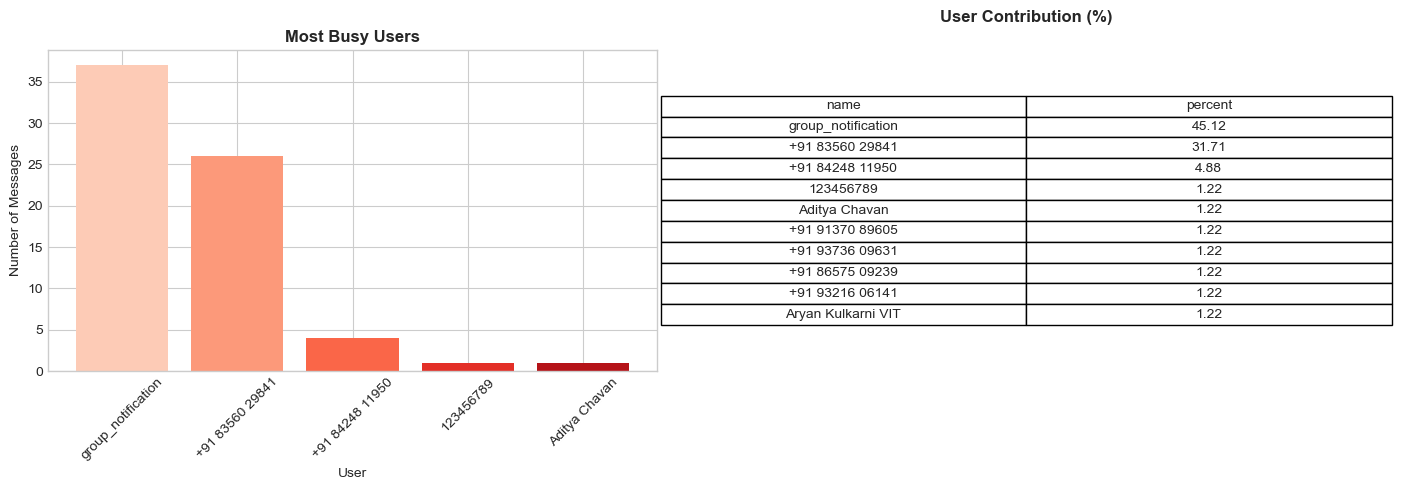

In [12]:
if selected_user == 'Overall':
    x, percent_df = most_busy_users(df)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.Reds(range(50, 256, 40))[:len(x)]
    axes[0].bar(x.index, x.values, color=colors)
    axes[0].set_title('Most Busy Users', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('User')
    axes[0].set_ylabel('Number of Messages')
    axes[0].tick_params(axis='x', rotation=45)
    axes[1].axis('off')
    table = axes[1].table(
        cellText=percent_df.head(10).values,
        colLabels=percent_df.columns,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    axes[1].set_title('User Contribution (%)', fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("User analysis is only available when 'Overall' is selected.")

### Word Cloud

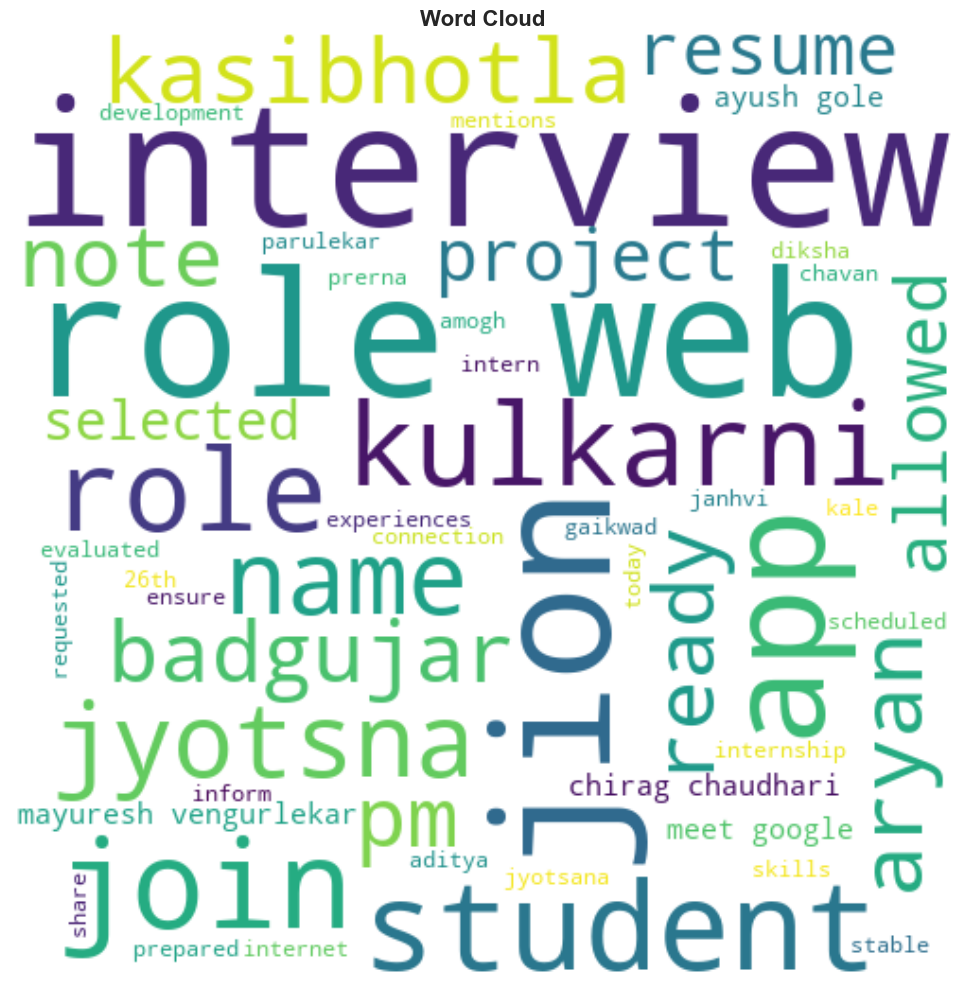

In [13]:
df_wc = create_wordcloud(selected_user, df, stop_words)

if df_wc:
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(df_wc, interpolation='bilinear')
    ax.axis('off')
    plt.title('Word Cloud', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough text data to generate word cloud.")

### Most Common Words

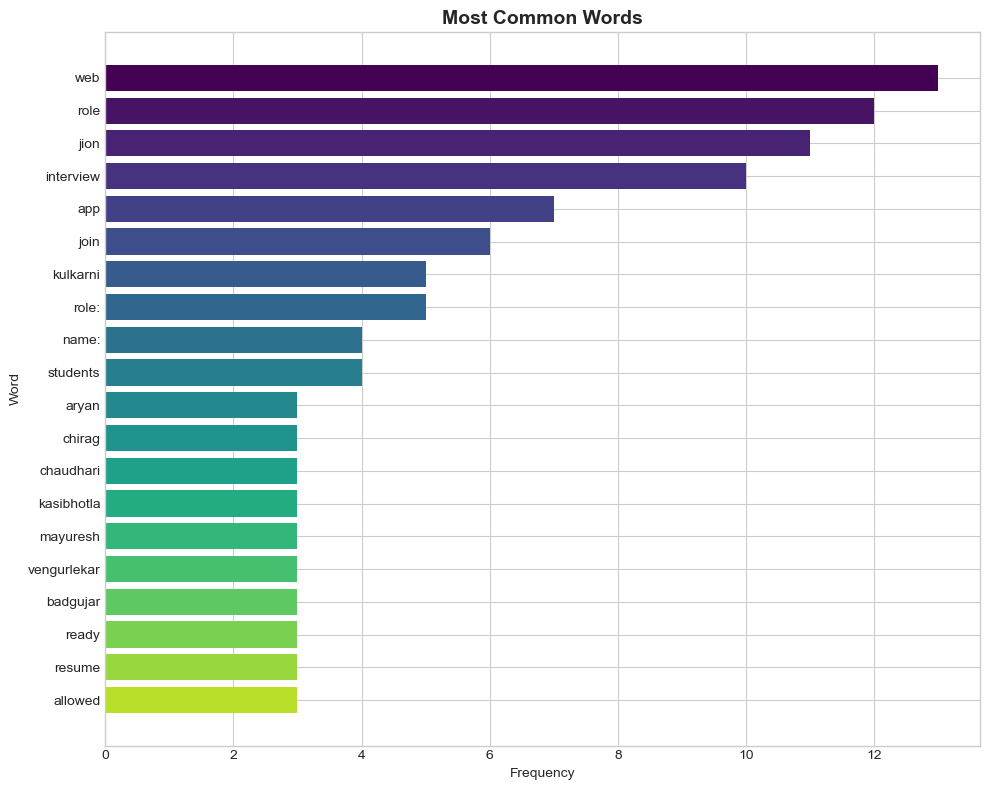

In [14]:
common_words_df = most_common_words(selected_user, df, stop_words)

if not common_words_df.empty:
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.viridis(range(0, 256, 12))[:len(common_words_df)]
    ax.barh(common_words_df['word'], common_words_df['count'], color=colors)
    ax.invert_yaxis()
    plt.xlabel('Frequency')
    plt.ylabel('Word')
    plt.title('Most Common Words', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No common words found.")

### Emoji Analysis

In [15]:
emoji_df = emoji_helper(selected_user, df)

if not emoji_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].axis('off')
    top_emojis = emoji_df.head(15)
    table = axes[0].table(
        cellText=top_emojis.values,
        colLabels=['Emoji', 'Count'],
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1.5, 2)
    axes[0].set_title('Top Emojis Used', fontsize=14, fontweight='bold', pad=20)
    top_5 = emoji_df.head(5)
    axes[1].pie(
        top_5['count'], 
        labels=top_5['emoji'], 
        autopct='%1.1f%%',
        colors=plt.cm.Pastel1.colors[:5],
        textprops={'fontsize': 20}
    )
    axes[1].set_title('Emoji Distribution (Top 5)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No emojis found in the selected messages.")

No emojis found in the selected messages.
